In [2]:
import pandas as pd 

df = pd.read_csv('csv_files/phishing_email.csv')
print(df.shape)
print(df.head())

(82486, 2)
                                       text_combined  label
0  hpl nom may 25 2001 see attached file hplno 52...      0
1  nom actual vols 24 th forwarded sabrae zajac h...      0
2  enron actuals march 30 april 1 201 estimated a...      0
3  hpl nom may 30 2001 see attached file hplno 53...      0
4  hpl nom june 1 2001 see attached file hplno 60...      0


In [3]:
print(df['label'].value_counts())
print(df.isnull().sum())

label
1    42891
0    39595
Name: count, dtype: int64
text_combined    0
label            0
dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

X = df['text_combined']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7935
           1       0.98      0.95      0.96      8563

    accuracy                           0.96     16498
   macro avg       0.96      0.96      0.96     16498
weighted avg       0.96      0.96      0.96     16498



         count         mean           std   min    25%    50%     75%  \
label                                                                   
0      39595.0  1536.096098   3695.897909  11.0  411.0  779.0  1493.0   
1      42891.0  1060.413793  21192.696303   1.0  241.0  391.0  1058.0   

             max  
label             
0       160318.0  
1      4279526.0  

Top phishing words:
[('2008', np.int64(32008)), ('10', np.int64(29428)), ('aug', np.int64(28037)), ('email', np.int64(26289)), ('company', np.int64(18244)), ('money', np.int64(17829)), ('account', np.int64(16337)), ('news', np.int64(15935)), ('cnncom', np.int64(14533)), ('time', np.int64(14143)), ('information', np.int64(12929)), ('daily', np.int64(12242)), ('cnn', np.int64(11711)), ('business', np.int64(11656)), ('new', np.int64(11498)), ('com', np.int64(10701)), ('bank', np.int64(10552)), ('click', np.int64(10467)), ('receive', np.int64(10188)), ('free', np.int64(9605))]

Top legit words:
[('enron', np.int64(53880)), ('e

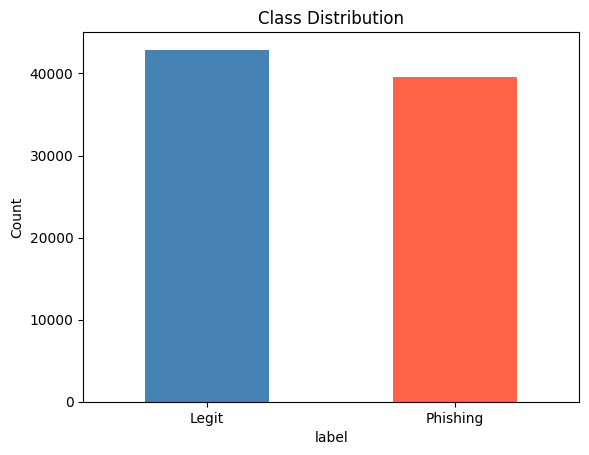

In [5]:
# EDA
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# 1. Email length distribution
df['email_length'] = df['text_combined'].str.len()
print(df.groupby('label')['email_length'].describe())

# 2. Top 20 words per class
def get_top_words(df, label, n=20):
    texts = df[df['label'] == label]['text_combined']
    cv = CountVectorizer(max_features=1000, stop_words='english')
    cv.fit_transform(texts)
    freqs = zip(cv.get_feature_names_out(), cv.transform(texts).toarray().sum(axis=0))
    return sorted(freqs, key=lambda x: x[1], reverse=True)[:n]

print("\nTop phishing words:")
print(get_top_words(df, 1))

print("\nTop legit words:")
print(get_top_words(df, 0))

# 3. Class distribution plot
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Class Distribution')
plt.xticks([0, 1], ['Legit', 'Phishing'], rotation=0)
plt.ylabel('Count')
plt.savefig('results/eda_class_distribution.png', bbox_inches='tight')
plt.show()

In [6]:
import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['cleaned'] = df['text_combined'].apply(clean_text)

# Compare original vs cleaned
print("Original:")
print(df['text_combined'][0])
print("\nCleaned:")
print(df['cleaned'][0])

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/rmp1931/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original:
hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls

Cleaned:
hpl nom may see attached file hplno xls hplno xls


In [7]:
X_clean = df['cleaned']
y = df['label']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y, test_size=0.2, random_state=42)

vectorizer_c = TfidfVectorizer(max_features=5000)
X_train_tfidf_c = vectorizer_c.fit_transform(X_train_c)
X_test_tfidf_c = vectorizer_c.transform(X_test_c)

model_nb_clean = MultinomialNB()
model_nb_clean.fit(X_train_tfidf_c, y_train_c)

y_pred_c = model_nb_clean.predict(X_test_tfidf_c)
print(classification_report(y_test_c, y_pred_c))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7935
           1       0.98      0.94      0.96      8563

    accuracy                           0.96     16498
   macro avg       0.96      0.96      0.96     16498
weighted avg       0.96      0.96      0.96     16498



In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf_c, y_train_c)

y_pred_lr = lr.predict(X_test_tfidf_c)
print("Logistic Regression:")
print(classification_report(y_test_c, y_pred_lr))

print("Naive Bayes:")
print(classification_report(y_test_c, y_pred_c))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7935
           1       0.98      0.98      0.98      8563

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498

Naive Bayes:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7935
           1       0.98      0.94      0.96      8563

    accuracy                           0.96     16498
   macro avg       0.96      0.96      0.96     16498
weighted avg       0.96      0.96      0.96     16498



In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf_c, y_train_c)
y_pred_rf = rf.predict(X_test_tfidf_c)
print("Random Forest:")
print(classification_report(y_test_c, y_pred_rf))

# Linear SVC
svc = LinearSVC(max_iter=1000)
svc.fit(X_train_tfidf_c, y_train_c)
y_pred_svc = svc.predict(X_test_tfidf_c)
print("Linear SVC:")
print(classification_report(y_test_c, y_pred_svc))

Random Forest:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7935
           1       0.99      0.98      0.98      8563

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498

Linear SVC:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7935
           1       0.98      0.99      0.98      8563

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498



/home/rmp1931/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/rmp1931/.local/lib/python3.12/site-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


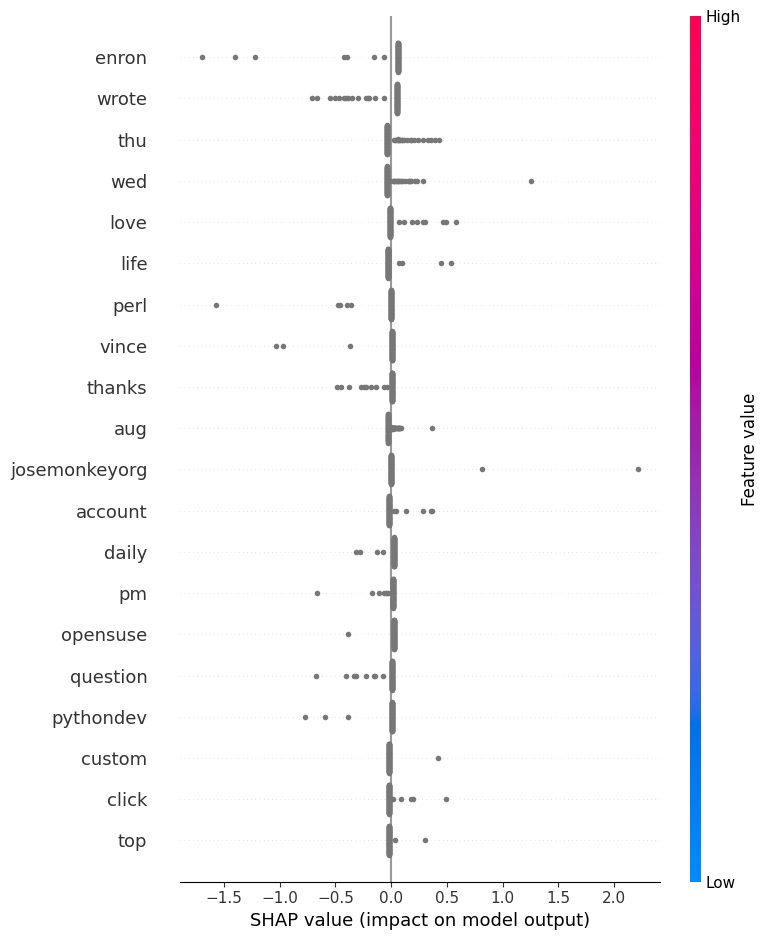

In [11]:
import shap
import lime
from lime.lime_text import LimeTextExplainer

# SHAP - top words that trigger phishing flag
explainer = shap.LinearExplainer(svc, X_train_tfidf_c, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_tfidf_c[:100])

shap.summary_plot(shap_values, X_test_tfidf_c[:100], 
                  feature_names=vectorizer_c.get_feature_names_out(),
                  show=True)

In [12]:
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X_test_tfidf_c[:100], 
                  feature_names=vectorizer_c.get_feature_names_out(),
                  show=False)
plt.savefig('results/shap_summary.png', bbox_inches='tight')
plt.close()

In [13]:
explainer_lime = LimeTextExplainer(class_names=['Legit', 'Phishing'])

def predict_proba(texts):
    tfidf = vectorizer_c.transform(texts)
    return svc.decision_function(tfidf).reshape(-1, 1) * [-1, 1]

sample_email = X_test_c.iloc[0]
exp = explainer_lime.explain_instance(sample_email, predict_proba, num_features=10)
exp.save_to_file('results/lime_explanation.html')
print("Sample email snippet:", sample_email[:200])
print("\nLIME top features:", exp.as_list())

Sample email snippet: endangered languages workshop foundation endangered languages pleased announce first workshop entitled steps language rescue take place university york weekend july year programme saturday arrival lat

LIME top features: [(np.str_('language'), -0.6481852322792743), (np.str_('languages'), -0.4458817403246486), (np.str_('university'), -0.41344755029731756), (np.str_('registration'), -0.22273264319458871), (np.str_('workshop'), -0.22126063620809847), (np.str_('policy'), -0.21144989507624498), (np.str_('pounds'), 0.11472204968508129), (np.str_('york'), 0.04188195411716611), (np.str_('inform'), 0.033233060289830835), (np.str_('session'), 0.03115200597672739)]


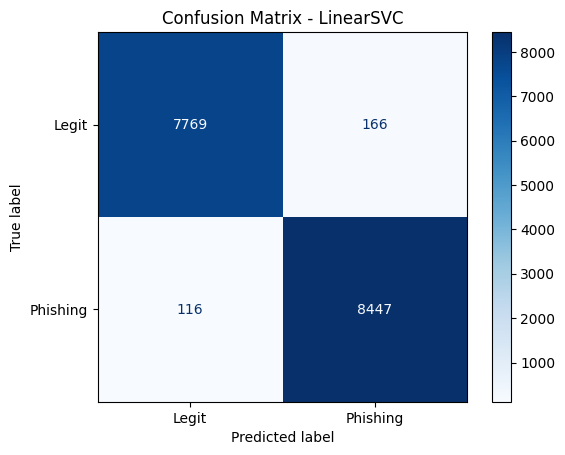

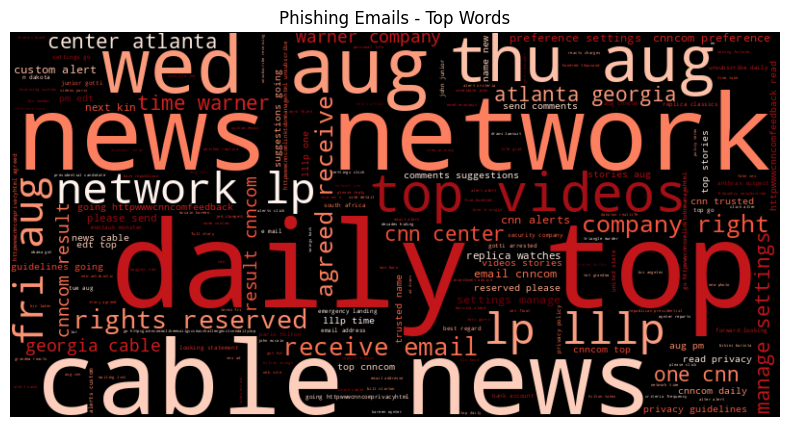

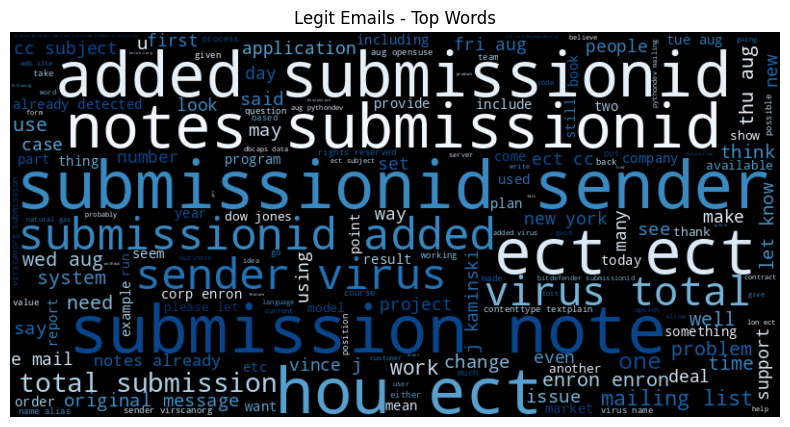

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from wordcloud import WordCloud

# 1. Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Phishing'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - LinearSVC')
plt.savefig('results/confusion_matrix.png', bbox_inches='tight')
plt.show()

# 2. Wordcloud - Phishing
phishing_text = ' '.join(df[df['label'] == 1]['cleaned'])
wc = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(phishing_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Phishing Emails - Top Words')
plt.savefig('results/wordcloud_phishing.png', bbox_inches='tight')
plt.show()

# 3. Wordcloud - Legit
legit_text = ' '.join(df[df['label'] == 0]['cleaned'])
wc2 = WordCloud(width=800, height=400, background_color='black', colormap='Blues').generate(legit_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc2, interpolation='bilinear')
plt.axis('off')
plt.title('Legit Emails - Top Words')
plt.savefig('results/wordcloud_legit.png', bbox_inches='tight')
plt.show()